# Esplorazione del corpus sintetico

Questo notebook analizza il corpus sintetico costruito per il training del mini-transformer didattico.
Il corpus è composto da frasi di ricette italiane con vocabolario controllato, progettato per permettere
al modello di apprendere pattern sintattici e dipendenze semantiche su scala ridotta.

## Composizione del corpus

Le 160 frasi sono distribuite su sette gruppi di complessità sintattica crescente:

| Gruppo | Struttura | Esempio | N |
|--------|-----------|---------|---|
| Semplice | V + Oggetto | *scaldate la padella .* | 20 |
| Con avverbio | V + Oggetto + Avv | *tagliate la cipolla piano .* | 20 |
| Con complemento | V + Oggetto + Prep + Compl | *versate l'olio nella padella .* | 25 |
| Coordinata | V + Obj + **e** + V + Obj | *tagliate la cipolla e aggiungete il sale .* | 20 |
| Sequenziale | V + Obj + **poi/quindi/infine** + V | *scaldate la padella poi versate l'olio .* | 35 |
| Subordinata | V + **finché** + sogg + V-stato | *lasciate cuocere finché il burro fonde .* | 25 |
| Mista | coordinazione + subordinazione | *aggiungete il burro e mescolate finché fonde .* | 15 |

Il vocabolario è composto da **55 token** che coprono: verbi imperativi (2ª plurale),
ingredienti, contenitori, articoli, preposizioni articolate, connettivi e aggettivi di stato
con accordo morfologico di genere.

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from pathlib import Path

In [8]:
CORPUS_PATH = Path("./data/transformer_corpus.json")

def load_corpus(path):
    with open(path) as f:
        return json.load(f)

vocabulary = []
data = load_corpus(CORPUS_PATH)
sentences_raw = data["sentences"]
for sentence in sentences_raw:
    tokens = sentence.split()
    vocabulary.extend(tokens)
vocabulary = list(set(vocabulary))

data['vocabulary'] = vocabulary

with open(CORPUS_PATH, 'w') as f:
    json.dump(data, f)

## Caricamento del corpus

In [9]:
CORPUS_PATH = Path("./data/transformer_corpus.json")

def load_corpus(path):
    with open(path) as f:
        return json.load(f)

data = load_corpus(CORPUS_PATH)
sentences_raw = data["sentences"]
vocabulary = data["vocabulary"]
tokenized = [s.split() for s in sentences_raw]

observed_vocab = set(t for s in tokenized for t in s)
print(f"Frasi nel corpus:          {len(sentences_raw)}")
print(f"Vocabolario dichiarato:    {data['vocabulary_size']} token")
print(f"Vocabolario osservato:     {len(observed_vocab)} token unici")
print(f"Copertura:                 {len(observed_vocab & set(vocabulary))}/{len(vocabulary)} token del vocabolario compaiono nelle frasi")

Frasi nel corpus:          160
Vocabolario dichiarato:    55 token
Vocabolario osservato:     56 token unici
Copertura:                 56/56 token del vocabolario compaiono nelle frasi


## Frequenza dei token

La distribuzione di frequenza mostra quali token dominano il corpus.
Ci aspettiamo che gli articoli e le preposizioni siano i più frequenti (token funzionali),
seguiti dai verbi e dagli ingredienti principali.

In [10]:
all_tokens = [t for s in tokenized for t in s]
freq = Counter(all_tokens)
freq_series = pd.Series(freq).sort_values(ascending=False)

print(f"Token totali nel corpus: {len(all_tokens)}")
print(f"\nTop 20 token per frequenza:")
print(freq_series.head(20).to_string())

Token totali nel corpus: 1045

Top 20 token per frequenza:
.             160
il             83
la             60
aggiungete     47
versate        37
poi            36
mescolate      33
padella        32
scaldate       32
finché         29
cuocete        28
nella          26
lentamente     26
e              25
latte          24
farina         22
cipolla        20
unite          20
burro          18
è              18


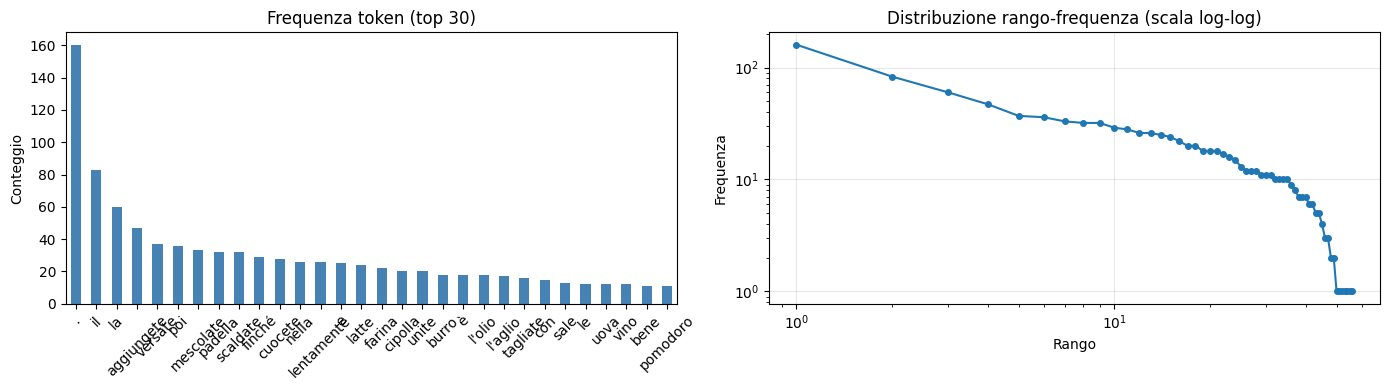

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Token frequency (top 30)
freq_series.head(30).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Frequenza token (top 30)')
axes[0].set_ylabel('Conteggio')
axes[0].tick_params(axis='x', rotation=45)

# Frequency rank-frequency (Zipf)
axes[1].loglog(range(1, len(freq_series) + 1), freq_series.values, 'o-', markersize=4)
axes[1].set_title('Distribuzione rango-frequenza (scala log-log)')
axes[1].set_xlabel('Rango')
axes[1].set_ylabel('Frequenza')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Lunghezza delle frasi

La lunghezza delle frasi determina la dimensione del contesto che il transformer dovrà gestire.
Frasi più lunghe richiedono un contesto più ampio e permettono al meccanismo di attenzione
di operare su dipendenze a distanza maggiore.

In [12]:
lengths = pd.Series([len(s) for s in tokenized], name='lunghezza')
print(lengths.describe().round(2))
print(f"\nDistribuzione delle lunghezze:")
print(lengths.value_counts().sort_index().to_string())

count    160.00
mean       6.53
std        1.71
min        3.00
25%        5.00
50%        7.00
75%        8.00
max       11.00
Name: lunghezza, dtype: float64

Distribuzione delle lunghezze:
lunghezza
3      6
4     21
5     18
6     19
7     49
8     34
9      7
10     5
11     1


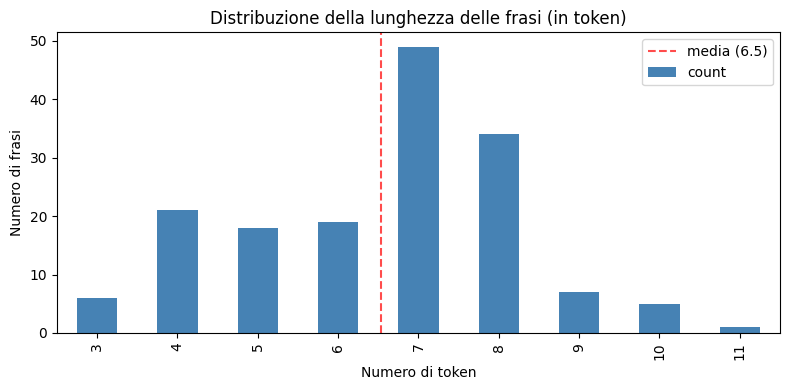

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
lengths.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribuzione della lunghezza delle frasi (in token)')
ax.set_xlabel('Numero di token')
ax.set_ylabel('Numero di frasi')
ax.axvline(x=lengths.mean() - lengths.min(), color='red', linestyle='--', alpha=0.7, label=f'media ({lengths.mean():.1f})')
ax.legend()
plt.tight_layout()
plt.show()

## Struttura sintattica

Classifichiamo le frasi in base ai connettivi presenti per verificare
che la distribuzione per gruppo corrisponda a quella progettata.

In [14]:
SEQUENCERS = {'poi', 'quindi', 'infine'}
SUBORDINATORS = {'finché'}
ADVERBS = {'bene', 'lentamente', 'piano', 'insieme'}
COMPLEMENTS = {'nella', 'nel', 'con', 'a'}

def classify_sentence(tokens):
    token_set = set(tokens)
    has_sub = bool(token_set & SUBORDINATORS)
    has_seq = bool(token_set & SEQUENCERS)
    has_coord = 'e' in token_set
    has_comp = bool(token_set & COMPLEMENTS)
    has_adv = bool(token_set & ADVERBS)

    if sum([has_sub, has_seq, has_coord]) >= 2:
        return 'mista'
    if has_sub:
        return 'subordinata (finché)'
    if has_seq:
        return 'sequenziale (poi/quindi/infine)'
    if has_coord:
        return 'coordinata (e)'
    if has_comp:
        return 'con complemento'
    if has_adv:
        return 'con avverbio'
    return 'semplice'

groups = [classify_sentence(s) for s in tokenized]
group_counts = pd.Series(Counter(groups)).sort_values(ascending=False)
print("Distribuzione per gruppo sintattico:")
print(group_counts.to_string())

Distribuzione per gruppo sintattico:
sequenziale (poi/quindi/infine)    43
con complemento                    25
subordinata (finché)               25
coordinata (e)                     22
semplice                           20
con avverbio                       20
mista                               5


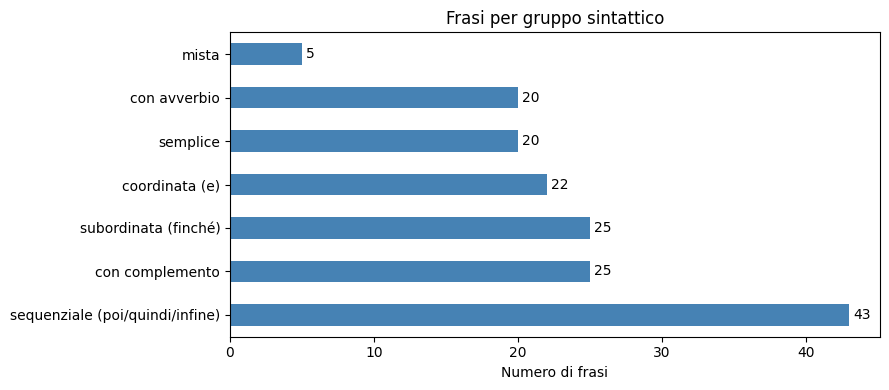

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
group_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Frasi per gruppo sintattico')
ax.set_xlabel('Numero di frasi')
for i, v in enumerate(group_counts.values):
    ax.text(v + 0.3, i, str(v), va='center')
plt.tight_layout()
plt.show()

## Co-occorrenze verbo–ingrediente

Questa matrice mostra quante volte ciascun verbo co-occorre con ciascun ingrediente
all'interno della stessa frase. Sono le dipendenze semantiche che ci aspettiamo che
il meccanismo di attenzione impari: `tagliate` tende ad apparire con `cipolla`, `aglio`, `pomodoro`;
`versate` con liquidi come `latte`, `vino`, `l'olio`.

In [16]:
VERBS = {'scaldate', 'tagliate', 'versate', 'aggiungete', 'unite',
         'coprite', 'togliete', 'cuocete', 'mescolate', 'lasciate'}
INGREDIENTS = {'farina', 'sale', 'burro', 'latte', 'cipolla',
               'pomodoro', 'vino', 'uova', 'zucchero', "l'olio", "l'aglio", "l'acqua"}

def build_cooccurrence_matrix(sentences, verbs, targets):
    matrix = defaultdict(Counter)
    for tokens in sentences:
        present_verbs = [t for t in tokens if t in verbs]
        present_targets = [t for t in tokens if t in targets]
        for v in present_verbs:
            for t in present_targets:
                matrix[v][t] += 1
    return pd.DataFrame(matrix).T.fillna(0).astype(int)

cooc = build_cooccurrence_matrix(tokenized, VERBS, INGREDIENTS)
cooc = cooc.loc[sorted(cooc.index), sorted(cooc.columns)]
print(cooc)

            burro  cipolla  farina  l'acqua  l'aglio  l'olio  latte  pomodoro  \
aggiungete     10        5       8        2        6       2      5         6   
coprite         0        0       0        1        0       0      1         0   
cuocete         0       15       0        0        8       0      0         7   
lasciate        1        1       0        1        0       0      2         0   
mescolate       9        0      11        0        0       0      5         0   
scaldate        2        1       1        0        2      11     10         0   
tagliate        0        7       0        0        5       2      0         4   
unite           4        0      14        0        0       0      2         0   
versate         0        2       1        5        5      13      8         0   

            sale  uova  vino  zucchero  
aggiungete    12     5     1         5  
coprite        0     0     0         0  
cuocete        0     0     6         0  
lasciate       0     0   

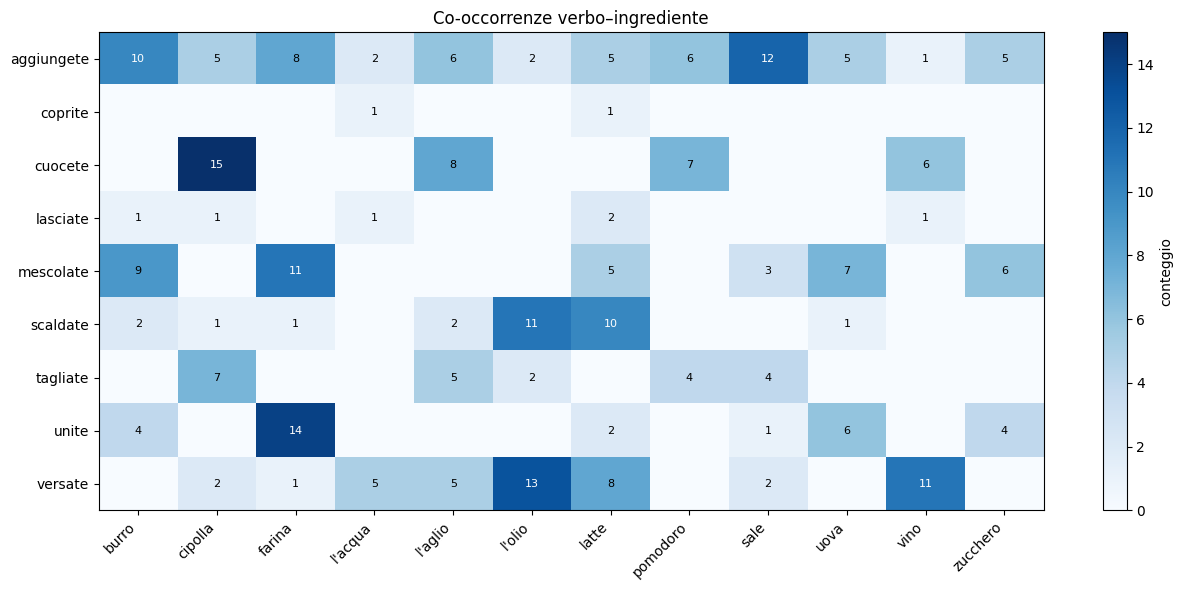

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(cooc.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(cooc.columns)))
ax.set_xticklabels(cooc.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cooc.index)))
ax.set_yticklabels(cooc.index)
ax.set_title('Co-occorrenze verbo–ingrediente')
plt.colorbar(im, ax=ax, label='conteggio')
for i in range(len(cooc.index)):
    for j in range(len(cooc.columns)):
        v = cooc.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8,
                    color='white' if v > cooc.values.max() * 0.6 else 'black')
plt.tight_layout()
plt.show()

## Stima della dimensione del contesto

Per il transformer, la dimensione del contesto (`context_len`) deve essere abbastanza grande
da contenere le frasi più lunghe del corpus. Verifichiamo la distribuzione dei percentili.

In [18]:
print("Percentili della lunghezza delle frasi:")
for p in [50, 75, 90, 95, 100]:
    print(f"  {p}° percentile: {lengths.quantile(p/100):.0f} token")

print(f"\nFrasi più lunghe del corpus (top 5):")
top_idx = lengths.nlargest(5).index
for i in top_idx:
    print(f"  [{lengths[i]:2d} token] {sentences_raw[i]}")

Percentili della lunghezza delle frasi:
  50° percentile: 7 token
  75° percentile: 8 token
  90° percentile: 8 token
  95° percentile: 9 token
  100° percentile: 11 token

Frasi più lunghe del corpus (top 5):
  [11 token] mescolate le uova con il latte poi aggiungete la farina .
  [10 token] mescolate il burro con lo zucchero finché è morbido .
  [10 token] unite le uova con la farina poi mescolate bene .
  [10 token] unite la farina con il burro poi mescolate bene .
  [10 token] aggiungete lo zucchero poi mescolate insieme finché è morbido .
